In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("smartcart_customers.csv")

In [3]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# Data Preprocessing

## 1. Handle Mising Values

In [4]:
df["Income"] = df["Income"].fillna(df["Income"].median())

In [5]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


## Feature Engineering

In [6]:
# Age
df["Age"] = 2026 - df["Year_Birth"]

# Customer Tenure Days
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"],dayfirst = True)
reference_date = df["Dt_Customer"].max()
df["Customer_Tenure_Days"] = (reference_date - df["Dt_Customer"]).dt.days

# Spending
df["Total_Spending"] = df["MntWines"] +  df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

# Children
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]


# Education 
df["Education"].value_counts()

# Undergraduate,Graduate,Postgraduate
df["Education"] = df["Education"].replace({
    "Basic" : "Undergraduate","2n Cycle":"Undergraduate",
    "Graduate" : "Graduate",
    "Master" : "Postgraduate","PhD":"Postgraduate"
})

#Marital Status
df["Living_With"] = df["Marital_Status"].replace({
    "Married" : "Partner","Together":"Partner",
    "Single" : "Alone","Divorced":"Alone",
    "Widow" : "Alone","Absurd":"Alone","YOLO":"Alone"
})

## Drop Columns

In [7]:
cols = ["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer"]
spending_cols = ["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]

cols_to_drop = cols + spending_cols
df_cleaned = df.drop(columns=cols_to_drop)

In [8]:
df_cleaned.shape

(2240, 15)

## Outliers

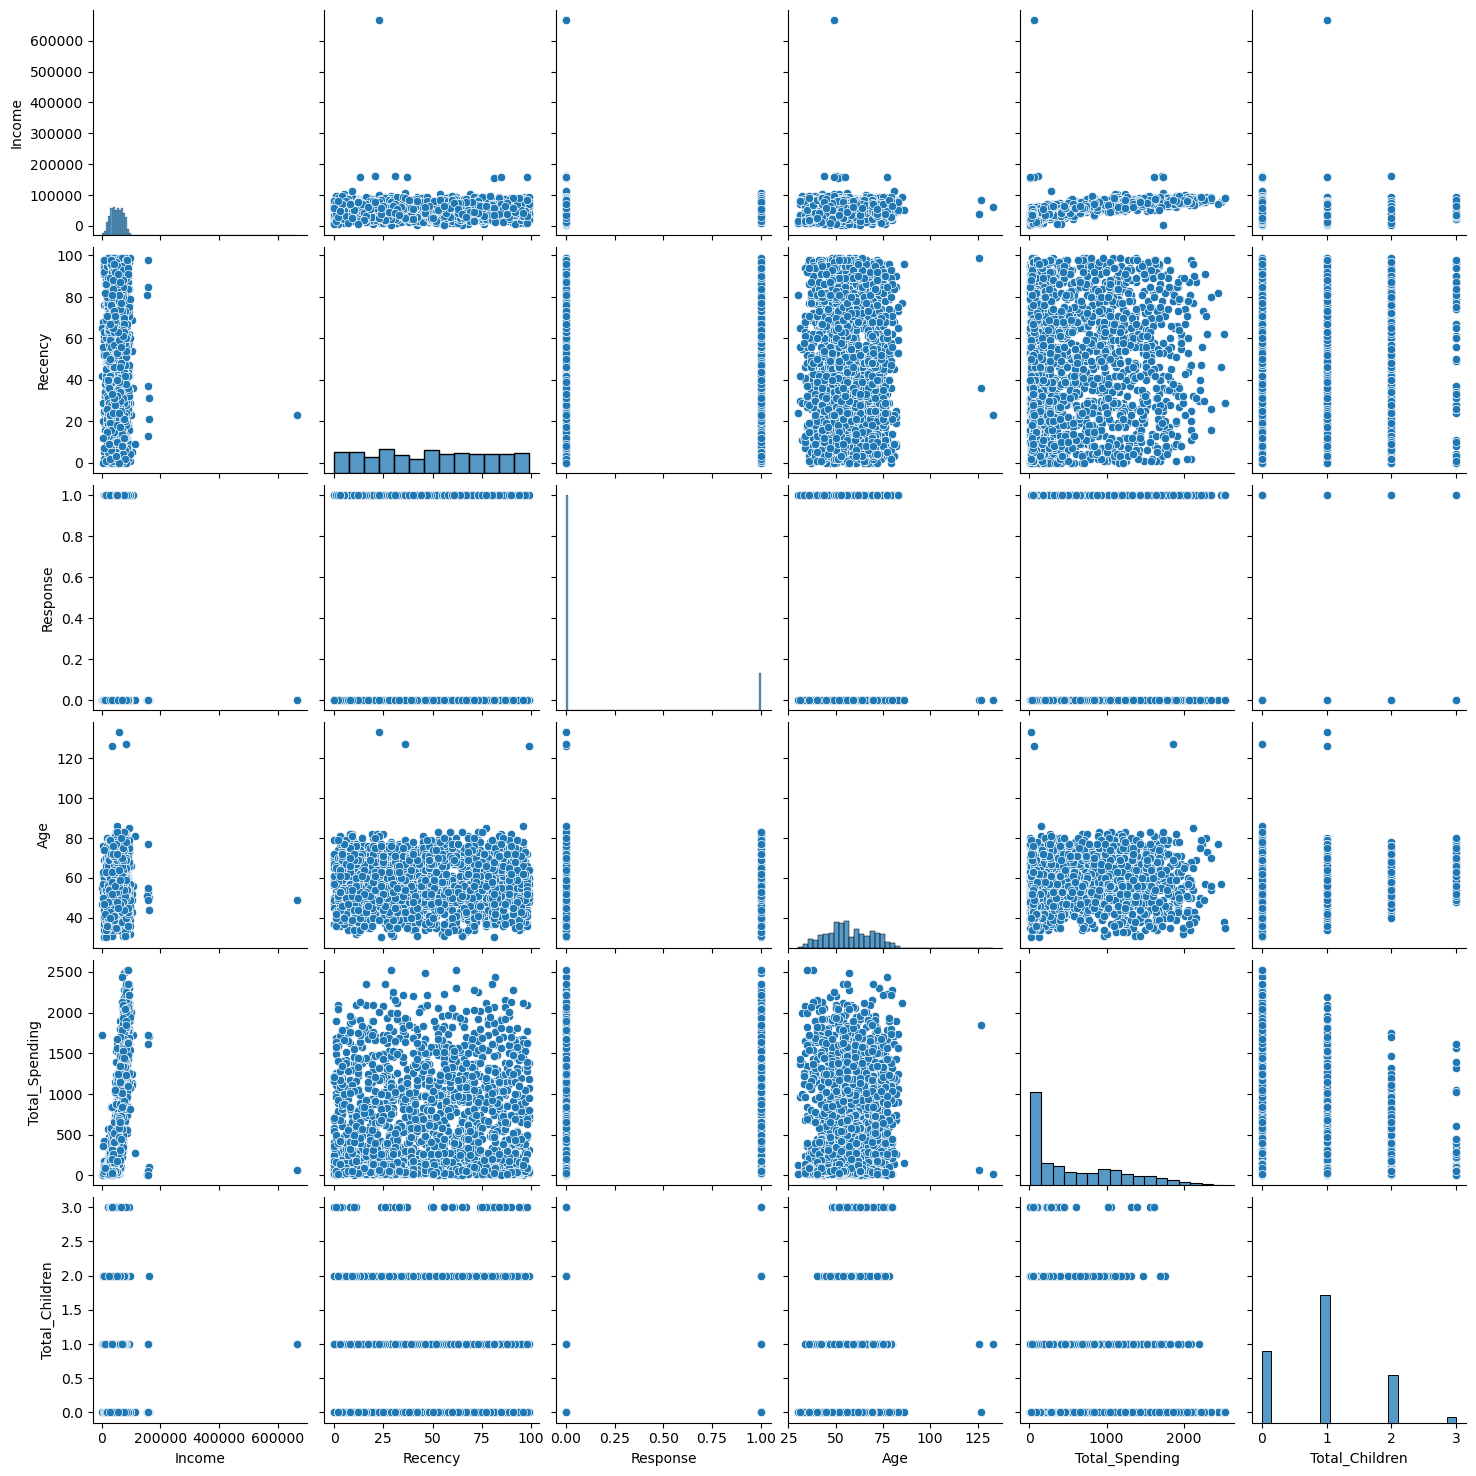

In [9]:
cols = ["Income","Recency","Response","Age","Total_Spending","Total_Children"]

#Pair Plots
sns.pairplot(df_cleaned[cols])

In [10]:
# Remove Outliers
print("data size with outliers:",len(df_cleaned))

df_cleaned =  df_cleaned[(df_cleaned["Age"]<90)]
df_cleaned =  df_cleaned[(df_cleaned["Income"]<600_000)]

print("data size without outliers:",len(df_cleaned))

data size with outliers: 2240
data size without outliers: 2236


## Heatmap

In [11]:
corr = df_cleaned.corr(numeric_only=True)

<Axes: >

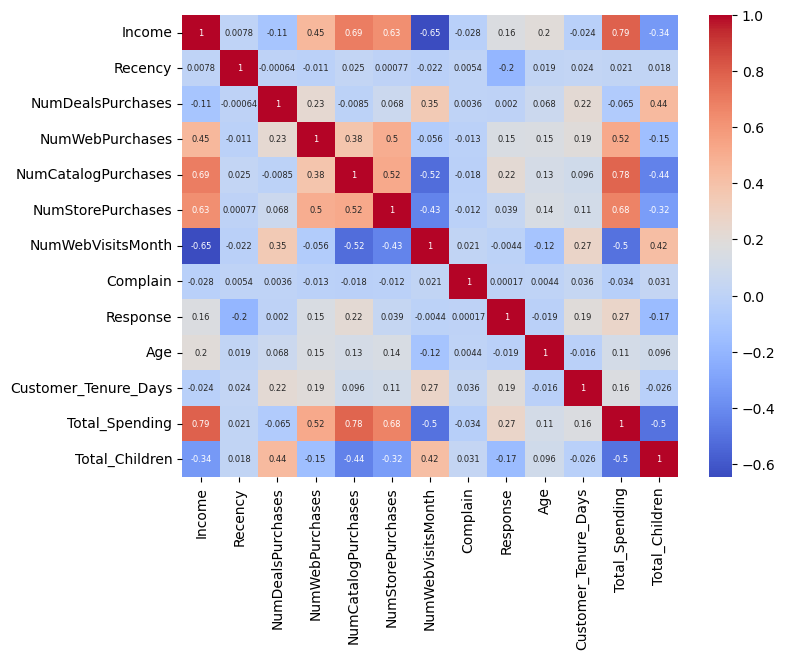

In [12]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size":6},
    cmap="coolwarm"
)

# Feature Encoding And Scaling

In [13]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

In [14]:
ohe = OneHotEncoder()
cat_cols =["Education","Living_With"]
enc_cols = ohe.fit_transform(df_cleaned[cat_cols])
enc_df = pd.DataFrame(enc_cols.toarray(),columns=ohe.get_feature_names_out(cat_cols),index=df_cleaned.index)
df_encoded =  pd.concat([df_cleaned.drop(columns = cat_cols),enc_df],axis=1)

In [15]:
X = df_encoded
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Visualize

In [16]:
from sklearn.decomposition import PCA

In [17]:
pca = PCA(n_components = 4)
X_pca = pca.fit_transform(X_scaled)
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815, 0.09912103])

Text(0.5, 0.92, '3d projction')

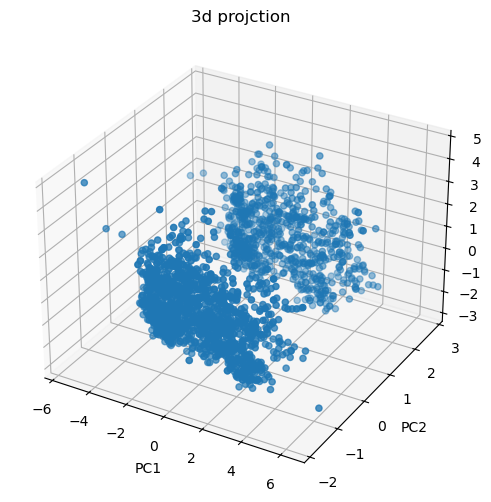

In [18]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:, 0],X_pca[:, 1],X_pca[:, 2])
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3d projction")

# Analyze K Value

# 1.Elbow Method

In [19]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss =[]
for k in range(1,11):
    kmeans = KMeans(n_clusters=k,random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

Text(0, 0.5, 'WCSS')

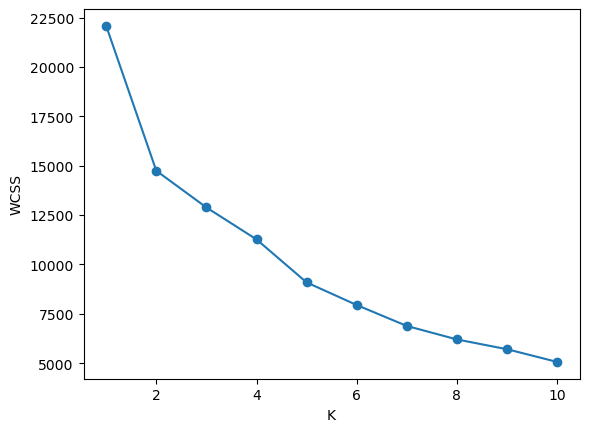

In [20]:
knee = KneeLocator(range(1,11), wcss, curve="convex", direction="decreasing")
optimal_k = knee.elbow
plt.plot(range(1,11), wcss, marker="o")
plt.xlabel("K")
plt.ylabel("WCSS")

## 2.Silhouette Score

Text(0, 0.5, 'Silhouette Score')

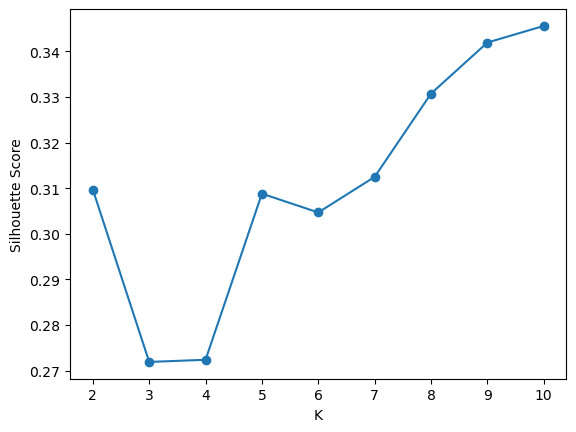

In [21]:
from sklearn.metrics import silhouette_score

scores = []
for k in range(2,11):
      kmeans = KMeans(n_clusters=k,random_state=42)
      labels = kmeans.fit_predict(X_pca)
      score = silhouette_score(X_pca,labels)
      scores.append(score)

# Plot
plt.plot(range(2,11), scores, marker="o")
plt.xlabel("K")
plt.ylabel("Silhouette Score")

Text(0, 0.5, 'Silouette Scores')

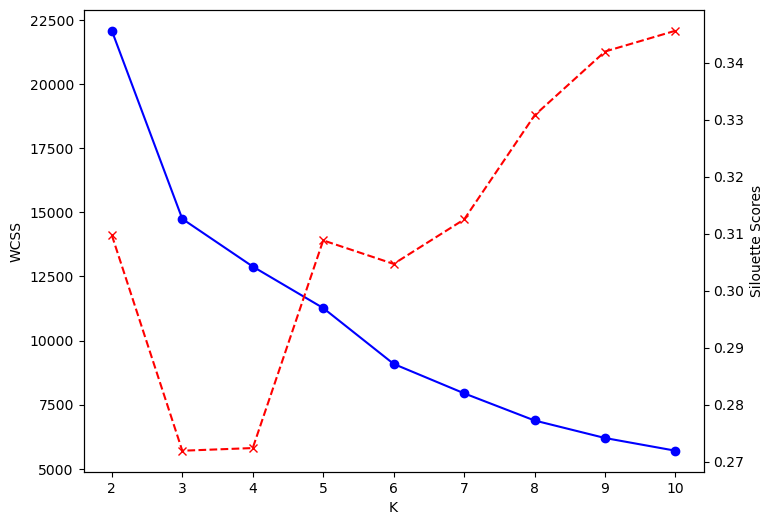

In [22]:
# Combined Plot
k_range = range(2,11)
fig ,ax1 = plt.subplots(figsize=(8,6))

ax1.plot(k_range,wcss[:len(k_range)],marker="o",color="blue")
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx()
ax2.plot(k_range,scores[:len(k_range)],marker="x",color="red",linestyle="--")
ax2.set_ylabel("Silouette Scores")

## Clustering

# K Means Clustering

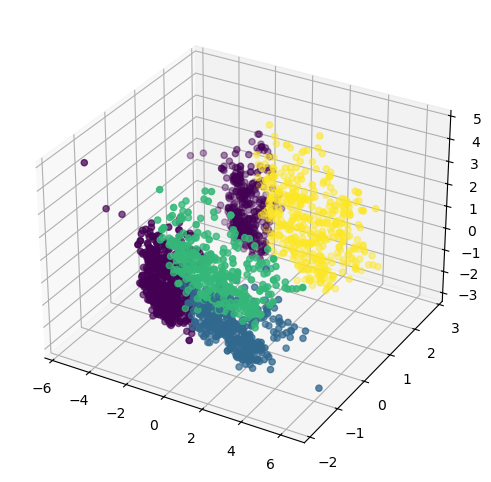

In [23]:
kmeans = KMeans(n_clusters=4,random_state=42)
labels_kmeans = kmeans.fit_predict(X_pca)

#Plot
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:, 0],X_pca[:, 1],X_pca[:, 2],c=labels_kmeans)

# Agglomerative Clustering

In [24]:
from sklearn.cluster import AgglomerativeClustering

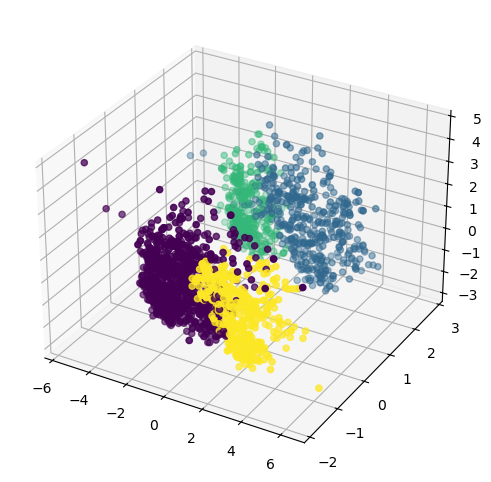

In [25]:
agg_clf = AgglomerativeClustering(n_clusters =4,linkage ="ward")
labels_agg = agg_clf.fit_predict(X_pca)
#Plot
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:, 0],X_pca[:, 1],X_pca[:, 2],c=labels_agg)

# Characterization of Clusters

In [26]:
X["cluster"] = labels_agg

<Axes: xlabel='cluster', ylabel='count'>

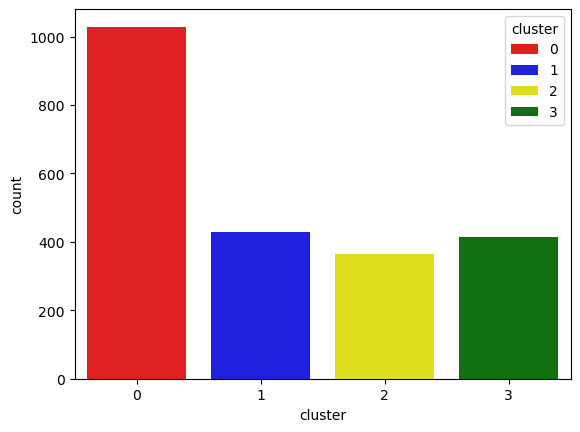

In [27]:
pal = ["red","blue","yellow","green"]
sns.countplot(x=X["cluster"],palette=pal,hue=X["cluster"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

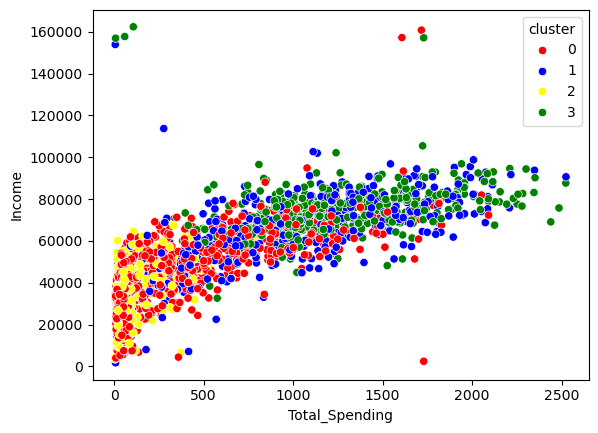

In [28]:
# Income and spending patterns 
sns.scatterplot(x=X["Total_Spending"],y=X["Income"],hue=X["cluster"],palette=pal)

# Cluster Summary

In [29]:
cluster_summary = X.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        42706.420797  49.697765           2.768707         3.635569   
1        66279.404651  49.439535           2.430233         5.700000   
2        35326.263736  49.038462           2.049451         2.189560   
3        74726.958838  47.399516           1.358354         5.208232   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   1.430515           4.661808           6.282799  0.010690   
1                   4.462791           7.893023           4.390698  0.006977   
2                   0.612637           3.269231           6.390110  0.010989   
3                   5.668281           8.663438           2.939467  0.004843   

         Response        Age  Customer_Tenure_Days  Total_Spending  \
cluster         